In [10]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
# import cardpy
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat

import numpy as np
import h5py
from   cardpy.FT_Operators import fft2c, ifft2c 
from cardpy.Data_Import import NifTi_Reader
from matplotlib import pyplot as plt     
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *

from dipy.core.histeq import histeq
from dipy.data import get_fnames
from dipy.segment.mask import median_otsu
import os
import scipy
import nrrd

cDTI_cmaps     = cDTI_Colormaps_Generator()

In [11]:
import subprocess
import os
import numpy as np

def normalize_complex_image(img_complex, target_value=1000, percentile=95):
    """
    Normalize a complex MRI image using the given percentile of the magnitude,
    then reconstruct the complex image as magnitude * exp(1j * phase).

    Parameters:
        img_complex : np.ndarray
            Coil-combined complex image
        target_value : float
            Desired value for the chosen percentile after scaling
        percentile : float
            Percentile of the magnitude to use for scaling (0-100)

    Returns:
        img_complex_scaled : np.ndarray
            Complex image scaled, phase preserved
        img_mag_scaled : np.ndarray
            Magnitude image ready for DICOM/export
        rescale_slope : float
            Applied scaling factor
    """
    # Compute magnitude and phase
    img_mag = np.abs(img_complex)
    img_phase = np.angle(img_complex)

    # Compute the percentile of the magnitude
    p_val = np.nanpercentile(img_mag, percentile)

    # Compute scaling factor
    rescale_slope = target_value / (p_val + 1e-12)

    # Scale magnitude
    img_mag_scaled = img_mag * rescale_slope

    # Reconstruct complex image
    img_complex_scaled = img_mag_scaled * np.exp(1j * img_phase)

    return img_complex_scaled, img_mag_scaled, rescale_slope

# Example usage:
# img_complex_scaled, img_mag_scaled, slope = normalize_complex_image(img_complex, target_value=1000, percentile=95)
# print("RescaleSlope:", slope)

def bg_phs_removal(data):
    original_matrix = data
    rows                            = original_matrix.shape[0]                                                                      # Extract number of rows
    columns                         = original_matrix.shape[1]                                                                      # Extract number of columns
    slices                          = original_matrix.shape[2]                                                                      # Extract number of slices
    directions                      = original_matrix.shape[3]                                                                      # Extract number of directions
                                                                        # Extract number of averages
    background_phase_removed_matrix = np.zeros(original_matrix.shape)                                                               # Initalize background phased removed matrix
    background_phase_removed_matrix = background_phase_removed_matrix.astype(np.complex128)                                         # Cast background phased removed matrix as complex
    rows_subdivide = int(np.rint(np.nextafter(rows / 8,  rows / 8 + 1)))                                                            # Subdivide rows in to 8ths
    rows_keep      = rows - (rows_subdivide * 2)                                                                                    # Keep ~75% of rows
    pad_rows_num   = rows_subdivide                                                                                                 # Determine number of rows to pad on each side
    cols_subdivide = int(np.rint(np.nextafter(columns / 8,  columns / 8 + 1)))                                                      # Subdivide columns in to 8ths
    cols_keep      = columns - (cols_subdivide * 2)                                                                                 # Keep ~75% of columns
    pad_cols_num   = cols_subdivide                                                                                                 # Determine number of columns to pad on each side
    hamming_filter                  = np.sqrt(np.outer(np.hamming(rows_keep), np.hamming(cols_keep)))                               # Creating hamming filter with
    background_phase_removal_filter = np.pad(hamming_filter, [(pad_rows_num, pad_rows_num), (pad_cols_num, pad_cols_num)])          # Pad with zeros back to original size
    for slc in range(slices):                                                                                                       # Iterate through slices
        for dif in range(directions):                                                                                               # Iterate through diffusion directions
                                                                                                # Iterate through averages
            original_image                 = original_matrix[:, :, slc, dif]                                                       # Store original image from original matrix
            filtered_kspace                = fft2c(original_image) * background_phase_removal_filter                                    # Apply background phase removal filter in k space
            background_phase_removed_image = ifft2c(filtered_kspace)                                                                    # Convert background phase removed k space to image space
            magnitude                      = np.abs(original_image)                                                                     # Store original magnitude data
            phase                          = np.exp(1j * np.angle(original_image))                                                      # Store original phase data
            phase_background_removed       = np.exp(1j * np.angle(background_phase_removed_image))                                      # Store background removed phase data
            background_phase_removed_matrix[:, :, slc, dif] = magnitude * (phase / phase_background_removed)                       # Apply phase background removal to complex data and store
    return background_phase_removed_matrix

In [12]:

# -------------------------------------------------------------------------
# Base paths and configuration
# -------------------------------------------------------------------------

overall_path = '/Volumes/T7/Stim-CODE/'

main_path = os.path.join(overall_path, 'NifTi')
bootstrappoing_path = os.path.join(overall_path, 'Bootstrapping')
volunteers = ['Phantom_Head']
volunteer = volunteers[0]


data_folders = [
    #'ep2d_diff_m0_ext_b1000_sos_mmt0',
    'trap_mmt0_Ncalib2',
    'gropt_mmt0_Ncalib2',
    'trap_mmt1_Ncalib2',
    'gropt_mmt1_Ncalib2',
]





# if volunteers[0] has phantom in the name
if volunteers[0].lower().find('phantom') != -1:
    mask_name = 'mask1' # mask is the isocenter mask
else:
    mask_name = 'mask1' # mask is the brain mask

phantom_name = volunteers[0]
    
process_folder = '02_Registered_Global'
process_file = 'Registered'
adc_folder = '04_DWI_Results'


Processing volunteer: Phantom_Head
Found 1 masks:
   - mask1.nrrd

--- Scan: trap_mmt0_Ncalib2 ---


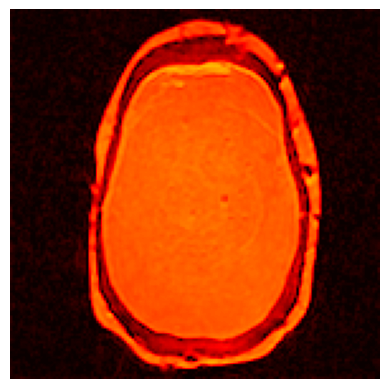

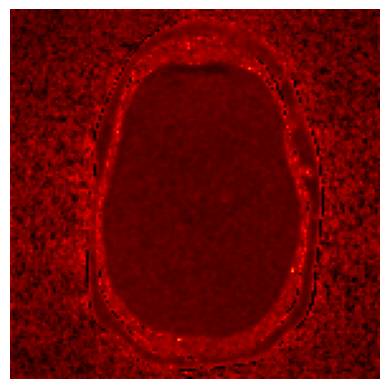

Median ADC (whole brain): 1.510
ML dADC (whole brain): 0.1150 and median dADC: 0.1173

--- Scan: gropt_mmt0_Ncalib2 ---


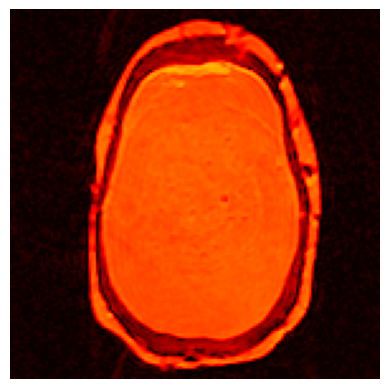

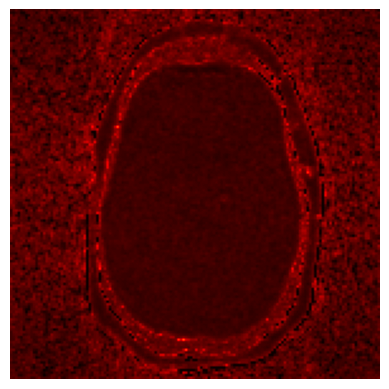

Median ADC (whole brain): 1.472
ML dADC (whole brain): 0.0750 and median dADC: 0.0777

--- Scan: trap_mmt1_Ncalib2 ---


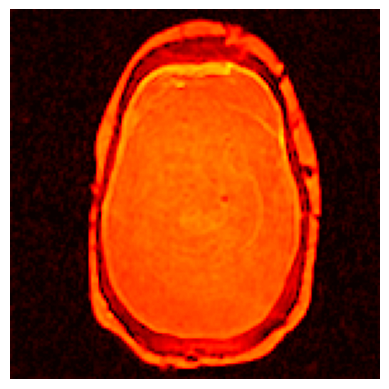

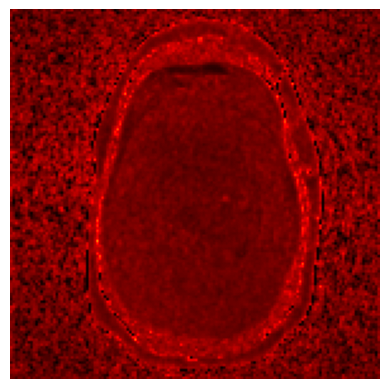

Median ADC (whole brain): 1.505
ML dADC (whole brain): 0.1450 and median dADC: 0.1498

--- Scan: gropt_mmt1_Ncalib2 ---


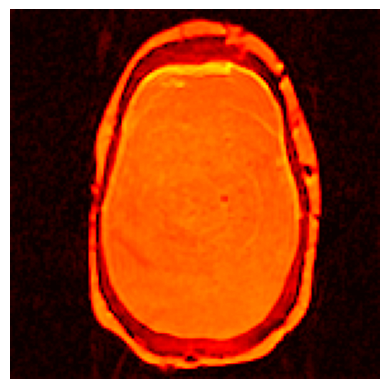

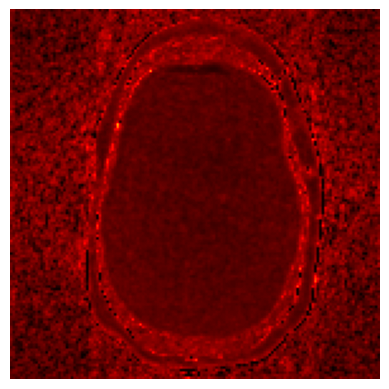

Median ADC (whole brain): 1.546
ML dADC (whole brain): 0.1150 and median dADC: 0.1149


In [13]:
# -------------------------------------------------------------------------
# Storage containers
# -------------------------------------------------------------------------
data_all_vols = {}
adc_all_vols = {}           # store ADC maps per scan
dadc_all_vols = {}          # store dADC maps per scan
mask_all_vols = {}          # stores selected mask per scan
maskbank_all_vols = {}      # stores all masks per volunteer
median_adc_all_vols = {}    # store median ADC in brain per scan
median_dADC_all_vols = {}   # store median dADC in brain per scan

# -------------------------------------------------------------------------
# Loop over volunteers
# -------------------------------------------------------------------------
for volunteer in volunteers:
    print(f"\n============================")
    print(f"Processing volunteer: {volunteer}")
    print(f"============================")

    data_all_vols[volunteer] = []
    adc_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []
    adc_all_vols[volunteer] = []
    dadc_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []
    median_dADC_all_vols[volunteer] = []

    # Dictionary to store all masks
    maskbank_all_vols[volunteer] = {}

    # ---------------------------------------------------------
    # 🔍 Load all masks for this volunteer
    # ---------------------------------------------------------
    volpath = os.path.join(main_path, volunteer)
    mask_files = [
        f for f in os.listdir(volpath)
        if f.endswith(".nrrd") and not f.startswith("._")
    ]

    print(f"Found {len(mask_files)} masks:")
    for mf in mask_files:
        print(f"   - {mf}")

    # if in vivo only load brain mask 
    
    for mf in mask_files:
        mpath = os.path.join(volpath, mf)
        mask_arr = nrrd.read(mpath)[0].astype('float32')
        if volunteer == 'Phantom_01B':
            mask_arr = np.flip(mask_arr, axis = 1)
        mask_arr[mask_arr == 0] = np.nan
        mask_arr = np.flip(mask_arr, axis=(0))
        mask_name_clean = os.path.splitext(mf)[0]
        maskbank_all_vols[volunteer][mask_name_clean] = mask_arr

        
    median_adc_all_vols[volunteer] = []
    median_dADC_all_vols[volunteer] = []

    # ---------------------------------------------------------
    # Loop over scans
    # ---------------------------------------------------------
    count = 0
    for folder in data_folders:
        print(f"\n--- Scan: {folder} ---")
        base_path = os.path.join(main_path, volunteer, folder)
        uncertainty_path = os.path.join(bootstrappoing_path, volunteer, folder)

        NifTi_path = os.path.join(base_path, process_folder, process_file + '.nii')
        b_values_path = os.path.join(base_path, process_folder, process_file + '.bvals')
        b_vectors_path = os.path.join(base_path, process_folder, process_file + '.bvecs')
        header_path = os.path.join(base_path, process_folder, process_file + '.header')
        adc_path = os.path.join(base_path, adc_folder, 'Standard_DWI_Metrics.mat')
        dADC_path = os.path.join(uncertainty_path,  'Invariant_Uncertainties.mat')

        # Skip if missing
        if not all(os.path.exists(p) for p in [NifTi_path, b_values_path, b_vectors_path, adc_path]):
            print(f"⚠️ Missing files for {folder}. Skipping.")
            continue

        # ---------------------------------------------------------
        # Load DWI
        # ---------------------------------------------------------
        [mat_stack, bvals_stack, bvecs_stack,
         Header, voxel_resolution, affine_matrix] = NifTi_Reader(
            NifTi_path, b_values_path, b_vectors_path, header_path, info='OFF'
        )

        tmp_norm, _, _ = normalize_complex_image(mat_stack, target_value=1000)
        tmp_bg_phs = np.real(bg_phs_removal(tmp_norm))
        [mat_sorted, bvals_sorted, bvecs_sorted] = stacked2sorted(
            tmp_bg_phs, bvals_stack, bvecs_stack
        )

        # Slice ordering correction
        if count == 0:
            Ns = mat_sorted.shape[2]
            odd = np.arange(0, Ns, 2)
            even = np.arange(1, Ns, 2)
            interleaved = np.concatenate([even, odd])
            inv_order = np.argsort(interleaved)
            mat_sorted = mat_sorted[:, :, inv_order, :, :]

        # Flip
        mat_sorted = np.flip(mat_sorted, axis=0)

        # ---------------------------------------------------------
        # Load ADC
        # ---------------------------------------------------------
        Standard_DWI_Metrics = scipy.io.loadmat(adc_path)
        adc_map = Standard_DWI_Metrics['ADC']  # shape: (X, Y, Z)
        adc_all_vols[volunteer].append(adc_map)
        plt.imshow(adc_map,vmin = 0, vmax = 3, cmap = 'hot')
        plt.axis('off')
        plt.show()

        # ---------------------------------------------------------
        # Load dADC
        # ---------------------------------------------------------
        Invariant_Uncertainties = scipy.io.loadmat(dADC_path)
        dADC_map = Invariant_Uncertainties['dADC']  # shape: (X, Y, Z)
        dadc_all_vols[volunteer].append(dADC_map)
        plt.imshow(dADC_map,vmin = 0, vmax = 1, cmap = 'hot')
        plt.axis('off')
        plt.show()


        # ---------------------------------------------------------
        # Median ADC in whole-brain mask (per volunteer, per scan)
        # ---------------------------------------------------------
        brain_mask = maskbank_all_vols[volunteer]['mask1']  # adjust key if needed

        adc_masked = adc_map * brain_mask
        adc_masked[adc_masked > 3] = np.nan
        adc_clean = adc_masked[np.isfinite(adc_masked) & (adc_masked > 0)]

        if adc_clean.size == 0:
            median_adc = np.nan
        else:
            median_adc = np.nanmedian(adc_clean)

        median_adc_all_vols[volunteer].append(median_adc)

        print(f"Median ADC (whole brain): {median_adc:.3f}")

        # ---------------------------------------------------------
        # Maximum-likelihood dADC in whole-brain mask (per volunteer, per scan)
        # ---------------------------------------------------------
        dADC_masked = dADC_map * brain_mask
        dADC_clean = dADC_masked[np.isfinite(dADC_masked) & (dADC_masked > 0)]

        if dADC_clean.size == 0:
            ml_dADC = np.nan
        else:
            # Histogram-based maximum likelihood (mode)
            num_bins = np.linspace(0, 4, 401)   # adjust range if needed for dADC
            vals, bin_edges = np.histogram(
                dADC_clean,
                bins=num_bins,
                range=(0, 4),
                density=True
            )

            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

            # Normalize to percentage (same as your MD code)
            h = (vals / np.sum(vals)) * 100

            ml_dADC = bin_centers[np.argmax(h)]

        print(f"ML dADC (whole brain): {ml_dADC:.4f} and median dADC: {np.nanmedian(dADC_clean):.4f}")
        median_dADC_all_vols[volunteer].append(ml_dADC)

        # ---------------------------------------------------------
        # Store DWI + selected mask
        # ---------------------------------------------------------
        tmp_brain_mask = brain_mask[...,np.newaxis,np.newaxis]
        tmp_brain_mask[np.isnan(tmp_brain_mask)] = 0
        data_all_vols[volunteer].append(mat_sorted)
        mask_to_use = maskbank_all_vols[volunteer][mask_name]  # selected mask
        mask_all_vols[volunteer].append(mask_to_use)

        count += 1


=== Plotting volunteer: Phantom_Head ===


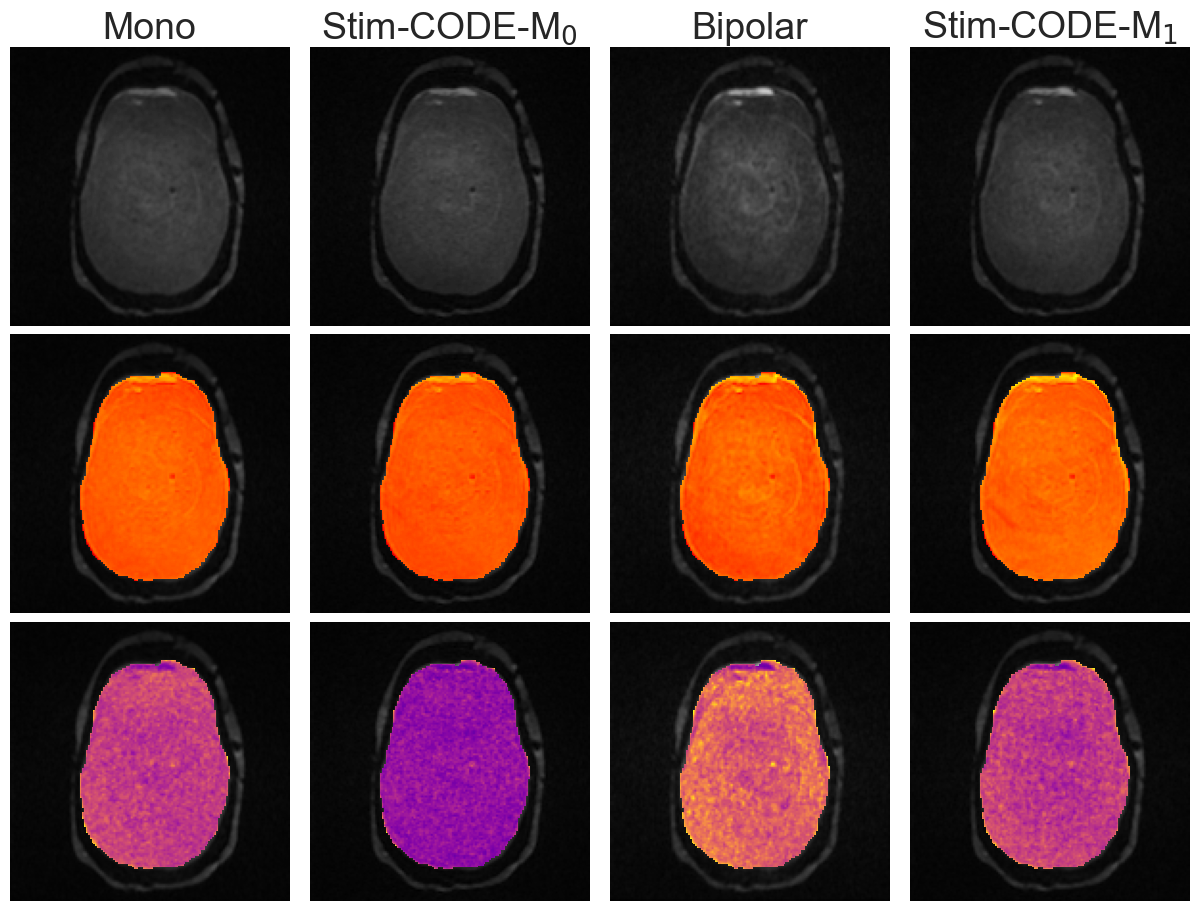

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ------------------------
# Global style
# ------------------------
mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

# ------------------------
# Settings
# ------------------------
plot_slices = {
    'V001': 0, 'V002': 0, 'V003': 0, 'V004': 0, 'V005': 0,
    'V006': 0, 'V007': 0, 'V008': 0, 'V009': 0, 'V010': 0,
    'Phantom': 0, 'Phantom_01B': 0, 'Phantom_DWI_repeat': 0,
    'Phantom_Sphere': 0, 'Phantom_DWI': 0, 'Phantom_Head': 0, 'Phantom_Head_repeat': 0
}

scans_to_plot = data_folders
diff_dir = 1

# Font sizes
title_fs = 27
ylabel_fs = 28
tick_fs = 18

# Color scale limits
dwi_vmin, dwi_vmax = 0, 800
adc_vmin, adc_vmax = 0, 3
dADC_vmin, dADC_vmax = 0, 0.25

# Column labels
col_labels = [
    #'Mono-Siemens', 
    'Mono', 'Stim-CODE-M$_0$',
    'Bipolar', 'Stim-CODE-M$_1$'
]

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting volunteer: {volunteer} ===")

    slice_idx = plot_slices[volunteer]
    n_rows = 3   # DWI / ADC / dADC
    n_cols = len(scans_to_plot)

    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 9),
        constrained_layout=True
    )

    if n_cols == 1:
        axs = axs[:, np.newaxis]

    # Row labels
    axs[0, 0].set_ylabel('DWI', fontsize=ylabel_fs)
    axs[1, 0].set_ylabel('ADC', fontsize=ylabel_fs)
    axs[2, 0].set_ylabel('dADC', fontsize=ylabel_fs)

    # ------------------------
    # Loop over scans (columns)
    # ------------------------
    for col_idx, folder in enumerate(scans_to_plot):

        try:
            idx_folder = data_folders.index(folder)
        except ValueError:
            print(f"⚠️ Folder {folder} not found for {volunteer}, skipping")
            continue

        # ------------------------
        # Row 0: DWI
        # ------------------------
        data = data_all_vols[volunteer][idx_folder]

        if col_labels[col_idx] == 'Mono-Siemens':
            dwi_img = np.nanmean(np.real(data), axis=-1)[:, :, slice_idx, 3]
        else:
            dwi_img = np.nanmean(np.real(data), axis=-1)[:, :, slice_idx, diff_dir]

        axs[0, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )
        axs[0, col_idx].set_title(col_labels[col_idx], fontsize=title_fs)
        axs[0, col_idx].axis('off')

        # ------------------------
        # Row 1: ADC + masks
        # ------------------------
        adc_img = adc_all_vols[volunteer][idx_folder][:, :, slice_idx]

        axs[1, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )

        for mask_name, mask_arr in maskbank_all_vols[volunteer].items():
            mask_slice = mask_arr[:, :, slice_idx].copy()
            mask_slice[mask_slice == 0] = np.nan
            adc_masked = adc_img * mask_slice

            axs[1, col_idx].imshow(
                adc_masked,
                cmap='hot',
                alpha=1,
                vmin=adc_vmin,
                vmax=adc_vmax
            )

        axs[1, col_idx].axis('off')

        # ------------------------
        # Row 2: dADC + masks
        # ------------------------
        dADC_img = dadc_all_vols[volunteer][idx_folder][:, :, slice_idx]

        axs[2, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )

        for mask_name, mask_arr in maskbank_all_vols[volunteer].items():
            mask_slice = mask_arr[:, :, slice_idx].copy()
            mask_slice[mask_slice == 0] = np.nan
            dADC_masked = dADC_img * mask_slice

            axs[2, col_idx].imshow(
                dADC_masked,
                cmap=sns.color_palette("plasma", as_cmap=True),
                alpha=1,
                vmin=dADC_vmin,
                vmax=dADC_vmax
            )

        axs[2, col_idx].axis('off')

    plt.show()

    fig.savefig(
        f'Fig_ADC_dADC_Overlays_{volunteer}.svg',
        dpi=300,
        bbox_inches='tight'
    )

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# User choices
# ====================================================
jitter       = 0.12

scan_names = data_folders
mask_names = list(maskbank_all_vols[phantom_name].keys())

palette = sns.color_palette("tab10", len(mask_names))

# ====================================================
# Pre-collect voxel-wise data
# ====================================================
phantom_adc  = {scan: {} for scan in scan_names}
phantom_dadc = {scan: {} for scan in scan_names}

for s, scan in enumerate(scan_names):

    adc_map  = adc_all_vols[phantom_name][s]
    dadc_map = dadc_all_vols[phantom_name][s]

    for mask_name in mask_names:
        mask = maskbank_all_vols[phantom_name][mask_name]

        # ---------- ADC ----------
        adc_vals = adc_map * mask
        adc_vals = adc_vals[
            np.isfinite(adc_vals) &
            (adc_vals > 0) &
            (adc_vals < 3)
        ]
        phantom_adc[scan][mask_name] = adc_vals

        # ---------- dADC ----------
        dadc_vals = dadc_map * mask
        dadc_vals = dadc_vals[
            np.isfinite(dadc_vals) &
            (dadc_vals > 0)
        ]
        phantom_dadc[scan][mask_name] = dadc_vals

        print(f"{scan:18s} | {mask_name:15s} | "
              f"ADC: {adc_vals.size:7d} | dADC: {dadc_vals.size:7d}")

trap_mmt0_Ncalib2  | mask1           | ADC:    6940 | dADC:    6940
gropt_mmt0_Ncalib2 | mask1           | ADC:    6940 | dADC:    6940
trap_mmt1_Ncalib2  | mask1           | ADC:    6940 | dADC:    6940
gropt_mmt1_Ncalib2 | mask1           | ADC:    6940 | dADC:    6940


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 24
TICK_FONTSIZE  = 18
SCATTER_SIZE   = 12

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# User choices
# ====================================================
jitter       = 0.10

scan_names = data_folders
mask_names = list(maskbank_all_vols[phantom_name].keys())

# Colors for metrics
ADC_COLOR  = '#1f77b4'
dADC_COLOR = '#d62728'

# ====================================================
# Pre-collect voxel-wise data
# ====================================================
phantom_adc  = {mask: {} for mask in mask_names}
phantom_dadc = {mask: {} for mask in mask_names}

for s, scan in enumerate(scan_names):

    adc_map  = adc_all_vols[phantom_name][s]
    dadc_map = dadc_all_vols[phantom_name][s]

    for mask in mask_names:
        m = maskbank_all_vols[phantom_name][mask]

        adc_vals = adc_map * m
        adc_vals = adc_vals[
            np.isfinite(adc_vals) &
            (adc_vals > 0) &
            (adc_vals < 3)
        ]
        phantom_adc[mask][scan] = adc_vals

        dadc_vals = dadc_map * m
        dadc_vals = dadc_vals[
            np.isfinite(dadc_vals) &
            (dadc_vals > 0)
        ]
        phantom_dadc[mask][scan] = dadc_vals

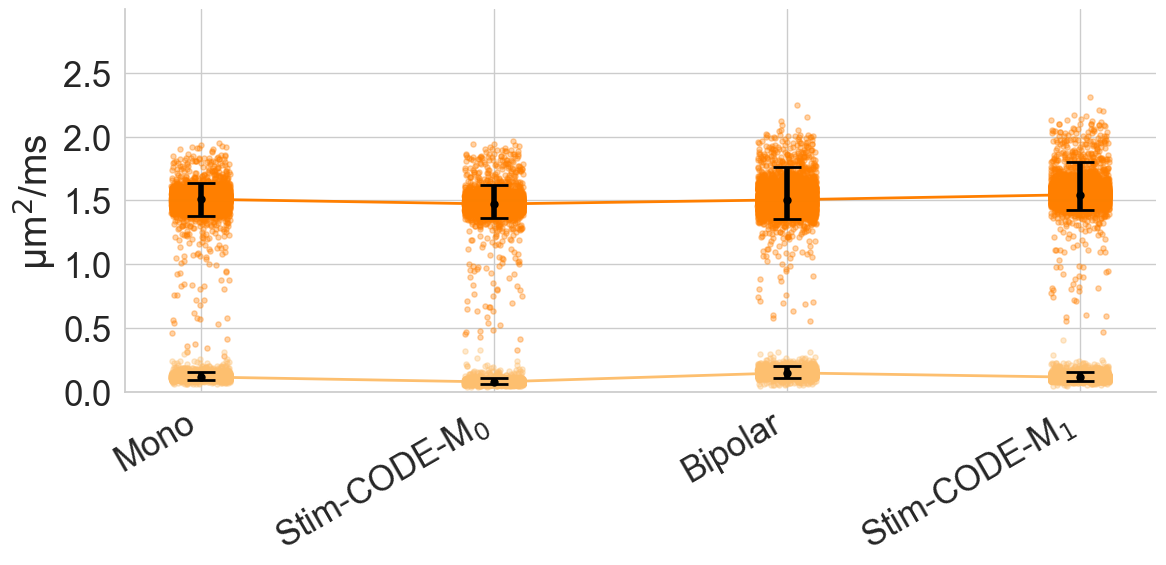

trap_mmt0_Ncalib2  | ADC:  1.510 [1.377, 1.639] | dADC: 0.1173 [0.0925, 0.1534]
gropt_mmt0_Ncalib2 | ADC:  1.472 [1.363, 1.623] | dADC: 0.0777 [0.0587, 0.1055]
trap_mmt1_Ncalib2  | ADC:  1.505 [1.352, 1.762] | dADC: 0.1498 [0.1110, 0.1994]
gropt_mmt1_Ncalib2 | ADC:  1.546 [1.422, 1.802] | dADC: 0.1149 [0.0862, 0.1578]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# =================== USER CONFIGURABLE =====================
# ============================================================
mask_to_plot = 'mask1'   # <-- change if needed

# Font sizes
TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 28
TICK_FONTSIZE  = 25

# Point / line sizes
SCATTER_SIZE = 14
DOT_SIZE     = 5
ERROR_LW     = 4.0
CAPSIZE      = 10
CAPTHICK     = 2

# Scatter jitter
JITTER = 0.10

# Colors
ADC_COLOR  = sns.color_palette('Paired', 10)[7]
dADC_COLOR = sns.color_palette('Paired', 10)[6]

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000

    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis=0).mean()
    upper_bound = np.percentile(bs, 97.5, axis=0).mean()

    return [np.nanmedian(data), lower_bound, upper_bound]

# ============================================================
# USER-DEFINED X-TICK LABELS
# ============================================================
scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]

xpos = np.arange(len(scan_names))

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

adc_medians  = []
dadc_medians = []

for s, scan in enumerate(scan_names):

    # --------------------------
    # ADC
    # --------------------------
    y_adc = phantom_adc[mask_to_plot][scan]
    ax.scatter(
        np.full_like(y_adc, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, size=len(y_adc)),
        y_adc,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=ADC_COLOR
    )

    mean_adc, lo_adc, hi_adc = bootstrap_ci(y_adc)
    adc_medians.append(mean_adc)

    ax.errorbar(
        xpos[s],
        mean_adc,
        yerr=[[mean_adc - lo_adc], [hi_adc - mean_adc]],
        fmt='o',
        color='black',
        lw=ERROR_LW,
        markersize=DOT_SIZE,
        capsize=CAPSIZE,
        capthick=CAPTHICK,
        zorder=10
    )

    # --------------------------
    # dADC
    # --------------------------
    y_dadc = phantom_dadc[mask_to_plot][scan]
    ax.scatter(
        np.full_like(y_dadc, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, size=len(y_dadc)),
        y_dadc,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=dADC_COLOR
    )

    mean_dadc, lo_dadc, hi_dadc = bootstrap_ci(y_dadc)
    dadc_medians.append(mean_dadc)

    ax.errorbar(
        xpos[s],
        mean_dadc,
        yerr=[[mean_dadc - lo_dadc], [hi_dadc - mean_dadc]],
        fmt='o',
        color='black',
        lw=ERROR_LW,
        markersize=DOT_SIZE,
        capsize=CAPSIZE,
        capthick=CAPTHICK,
        zorder=10
    )

# --------------------------
# Connect medians
# --------------------------
ax.plot(xpos, adc_medians,  color=ADC_COLOR,  lw=2)
ax.plot(xpos, dadc_medians, color=dADC_COLOR, lw=2)

# --------------------------
# Axis formatting
# --------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right', fontsize=TICK_FONTSIZE)
ax.set_ylabel('µm$^2$/ms', fontsize=LABEL_FONTSIZE)
ax.set_ylim([0, 3.])
ax.set_yticks(np.arange(0, 2.6, 0.5))
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_title(mask_to_plot, fontsize=TITLE_FONTSIZE)

plt.tight_layout()
plt.show()

fig.savefig(
    f'Fig_ADC_dADC_{mask_to_plot}.svg',
    dpi=300,
    bbox_inches='tight'
)


# print out medians and 95% CI
for s, scan in enumerate(scan_names):
    y_adc = phantom_adc[mask_to_plot][scan]
    mean_adc, lo_adc, hi_adc = bootstrap_ci(y_adc)

    y_dadc = phantom_dadc[mask_to_plot][scan]
    mean_dadc, lo_dadc, hi_dadc = bootstrap_ci(y_dadc)

    print(f"{scan:18s} | "
          f"ADC:  {mean_adc:.3f} [{lo_adc:.3f}, {hi_adc:.3f}] | "
          f"dADC: {mean_dadc:.4f} [{lo_dadc:.4f}, {hi_dadc:.4f}]")

AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

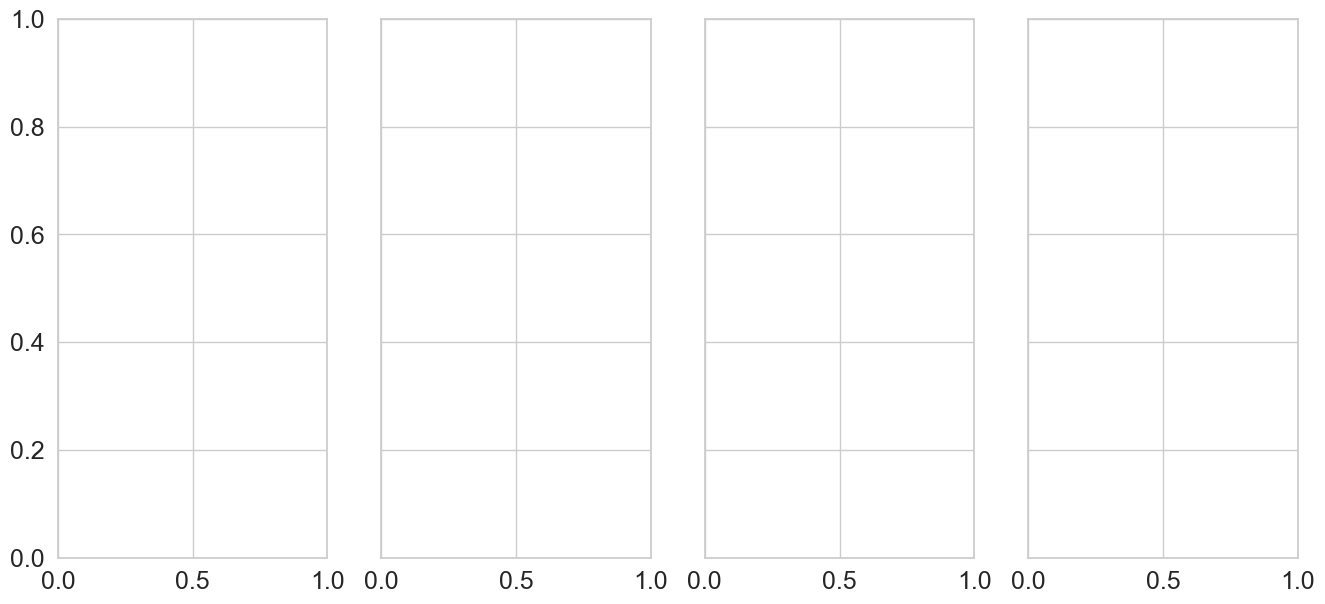

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# =================== USER CONFIGURABLE =====================
# ============================================================
# Font sizes
TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 25
TICK_FONTSIZE  = 23

# Point / line sizes
SCATTER_SIZE = 14      # individual sample points
DOT_SIZE     = 5      # black median point
ERROR_LW     = 4.0     # error bar thickness
CAPSIZE      = 10
CAPTHICK     = 2

# Scatter jitter
JITTER = 0.10

# Colors
ADC_COLOR  = sns.color_palette('Paired', 10)[7]
dADC_COLOR = sns.color_palette('Paired', 10)[6]

palette_adc  = [sns.color_palette('Paired', 10)[7]] * len(data_folders)
palette_dadc = [sns.color_palette('Paired', 10)[6]] * len(data_folders)


# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis = 0).mean()
    upper_bound = np.percentile(bs, 97.5, axis = 0).mean()
    CI_low  = lower_bound
    CI_high = upper_bound
    return [np.nanmedian(data),CI_low, CI_high]
# ============================================================
# USER-DEFINED X-TICK LABELS (CUSTOM)
# ============================================================
scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]  # must match len(scan_names)

# ============================================================
# Order masks by global ADC (highest first)
# ============================================================
mask_adc_means = {}
for mask in mask_names:
    all_adc = []
    for scan in scan_names:
        all_adc.append(phantom_adc[mask][scan])
    all_adc = np.concatenate(all_adc)
    mask_adc_means[mask] = np.nanmean(all_adc)

mask_names_sorted = sorted(mask_names, key=lambda m: mask_adc_means[m], reverse=True)

# ============================================================
# Plot setup
# ============================================================
n_masks = len(mask_names_sorted)
n_cols  = 4
n_rows  = int(np.ceil(n_masks / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16,7),
    sharey=True,
    sharex=True
)

axes = axes.flatten() if n_masks > 1 else [axes]
xpos = np.arange(len(scan_names))

# ============================================================
# Plotting loop
# ============================================================

for ax_idx, mask in enumerate(mask_names_sorted):
    ax = axes[ax_idx]

    adc_medians = []
    dadc_medians = []

    for s, scan in enumerate(scan_names):
        # --------------------------
        # ADC
        # --------------------------
        y_adc = phantom_adc[mask][scan]
        ax.scatter(
            np.full_like(y_adc, xpos[s]) +
            np.random.uniform(-JITTER, JITTER, size=len(y_adc)),
            y_adc,
            s=SCATTER_SIZE,
            alpha=0.35,
            color=ADC_COLOR
        )
        mean_val_adc, lo_adc, hi_adc = bootstrap_ci(y_adc)
        adc_medians.append(mean_val_adc)
        ax.errorbar(
            xpos[s],
            mean_val_adc,
            yerr=[[mean_val_adc - lo_adc], [hi_adc - mean_val_adc]],
            fmt='o',
            color='black',
            lw=ERROR_LW,
            markersize=DOT_SIZE,
            capsize=CAPSIZE,
            capthick=CAPTHICK,
            zorder=10
        )

        # --------------------------
        # dADC
        # --------------------------
        y_dadc = phantom_dadc[mask][scan]
        ax.scatter(
            np.full_like(y_dadc, xpos[s]) +
            np.random.uniform(-JITTER, JITTER, size=len(y_dadc)),
            y_dadc,
            s=SCATTER_SIZE,
            alpha=0.35,
            color=dADC_COLOR
        )
        mean_val_dadc, lo_dadc, hi_dadc = bootstrap_ci(y_dadc)
        dadc_medians.append(mean_val_dadc)
        ax.errorbar(
            xpos[s],
            mean_val_dadc,
            yerr=[[mean_val_dadc - lo_dadc], [hi_dadc - mean_val_dadc]],
            fmt='o',
            color='black',
            lw=ERROR_LW,
            markersize=DOT_SIZE,
            capsize=CAPSIZE,
            capthick=CAPTHICK,
            zorder=10
        )

    # --------------------------
    # Connect medians with a line
    # --------------------------
    ax.plot(xpos, adc_medians, color=ADC_COLOR, lw=2, linestyle='-')
    ax.plot(xpos, dadc_medians, color=dADC_COLOR, lw=2, linestyle='-')
    # --------------------------
    # Axis formatting
    # --------------------------
    ax.set_xticks(xpos)
    ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right', fontsize=TICK_FONTSIZE)
    ax.set_ylim([0, 2.1])
    ax.set_yticks(np.arange(0, 2.1, 0.5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Turn off empty subplots
for i in range(n_masks, n_rows * n_cols):
    fig.delaxes(axes[i])

# Shared y-label
axes[0].set_ylabel('µm$^2$/ms', fontsize=LABEL_FONTSIZE)

plt.tight_layout(w_pad=-1)

plt.show()

fig.savefig(
    f'Fig_ADC_dADC_Scatter_BootstrapCI_{phantom_name}.svg',
    dpi=300,
    bbox_inches='tight'
)

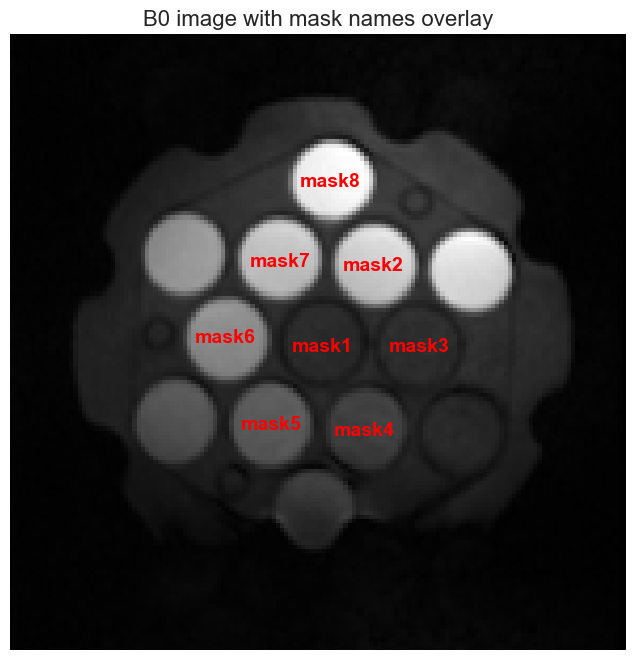

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# ============================================================
# Example: B0 image (2D slice)
# ============================================================
# Assume you have a 3D DWI/B0 image for a phantom
slice_idx = 0
B0_slice = dwi_img  # 2D slice or select slice from 3D array

plt.figure(figsize=(8, 8))
plt.imshow((B0_slice), cmap='gray', origin='lower')
plt.axis('off')

# ============================================================
# Overlay mask names according to subplot order
# ============================================================
n_cols = 4  # same as your subplot grid
n_rows = int(np.ceil(len(mask_names_sorted) / n_cols))

for subplot_idx, mask_name in enumerate(mask_names_sorted):

    # Get mask for this slice
    mask = maskbank_all_vols['Phantom_DWI_repeat'][mask_name][:, :, slice_idx]  # adjust volunteer key
    mask = np.nan_to_num(mask)  # replace NaNs with 0

    if mask.sum() == 0:
        continue

    # Compute centroid
    y0, x0 = center_of_mass(mask)

    # Overlay text: mask name
    plt.text(
        x0, y0,
        mask_name,
        color='red',
        fontsize=14,
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.title('B0 image with mask names overlay', fontsize=16)
plt.show()

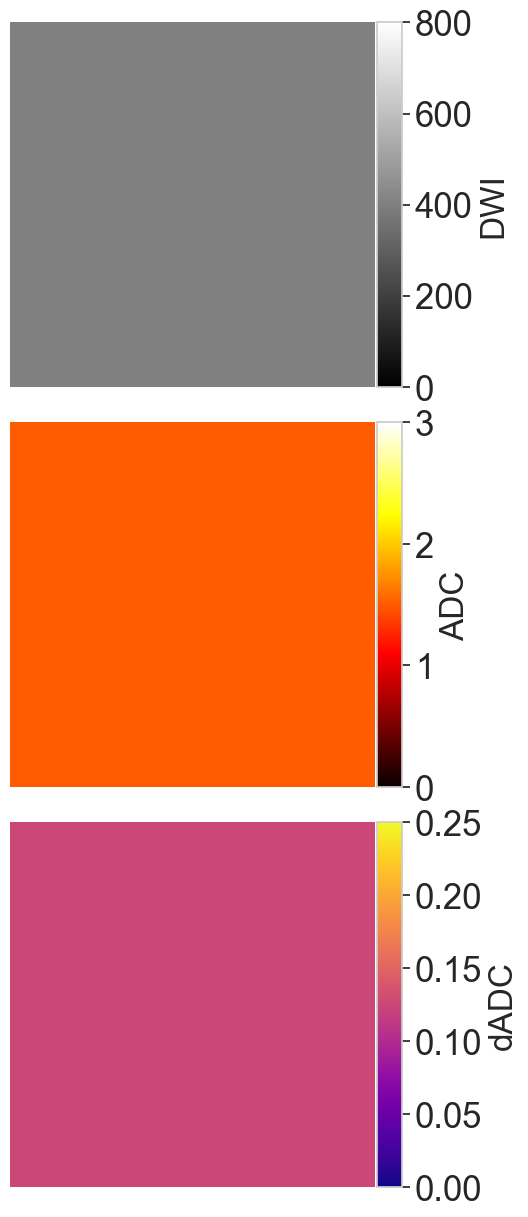

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------
# Dummy images for colorbars
# ------------------------
dwi_img_dummy = np.ones((1, 1)) * (dwi_vmin + dwi_vmax) / 2
adc_img_dummy = np.ones((1, 1)) * (adc_vmin + adc_vmax) / 2
dADC_img_dummy = np.ones((1, 1)) * (dADC_vmin + dADC_vmax) / 2

# ------------------------
# Stack into one figure
# ------------------------
fig, axs = plt.subplots(3, 1, figsize=(4, 12), constrained_layout=True)

# Control thickness and padding
cbar_width = 0.25  # fraction of axis width
cbar_pad   = 0.02

# Tick font size
cbar_tick_fs = 25

# Row 0: DWI
im0 = axs[0].imshow(dwi_img_dummy, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
axs[0].axis('off')
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size=cbar_width, pad=cbar_pad)
cb0 = fig.colorbar(im0, cax=cax0, label='DWI')
cb0.ax.tick_params(labelsize=cbar_tick_fs)

# Row 1: ADC
im1 = axs[1].imshow(adc_img_dummy, cmap='hot', vmin=adc_vmin, vmax=adc_vmax)
axs[1].axis('off')
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size=cbar_width, pad=cbar_pad)
cb1 = fig.colorbar(im1, cax=cax1, label='ADC')
cb1.ax.tick_params(labelsize=cbar_tick_fs)

# Row 2: dADC
im2 = axs[2].imshow(dADC_img_dummy, cmap=sns.color_palette("plasma", as_cmap=True),
                     vmin=dADC_vmin, vmax=dADC_vmax)
axs[2].axis('off')
divider2 = make_axes_locatable(axs[2])
cax2 = divider2.append_axes("right", size=cbar_width, pad=cbar_pad)
cb2 = fig.colorbar(im2, cax=cax2, label='dADC')
cb2.ax.tick_params(labelsize=cbar_tick_fs)

plt.show()
fig.savefig('stacked_colorbars_thick_ticks.svg', dpi=300, bbox_inches='tight')